<h1 style="text-align: center; font-size: 50px;"> 🤖 MLFlow Registration for Multimodal RAG Cacheless
</h1>

# MLFlow Model Service 

In this section, we demonstrate how to deploy a RAG-based chatbot service. This service provides a REST API endpoint that allows users to query the knowledge base with natural language questions, use any Azure DevOps Wikis as the knowledge base, and manage conversation history. This service encapsulates all the functionality we developed in this notebook, including the document retrieval system, RAG-based question answering capabilities, and MLFlow integration for observation and evaluation. For this specific service, we handle each new request with a refresh of the database for our cloud streamlit deployment, ensuring privacy across all users.

## Step 0: Imports and Environment Setup

In [1]:
import time
import os 
from pathlib import Path
import sys
import logging

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Create logger
logger = logging.getLogger("multimodal_rag_logger")
logger.setLevel(logging.INFO)
if not logger.handlers:
    formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
    stream_handler = logging.StreamHandler(sys.stdout)
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)
logger.propagate = False

In [2]:
start_time = time.time()  

logger.info("Notebook execution started.")

2025-10-10 18:34:37 - INFO - Notebook execution started.


In [3]:
%pip install -r ../requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
# === Standard Library Imports ===
import gc
import json
import base64
import tempfile
import threading
import shutil
import warnings
from rank_bm25 import BM25Okapi
from typing import Any, Dict, List, Optional, TypedDict
from collections import defaultdict
from IPython.display import display, Image, Markdown

# === Third-Party Library Imports ===
import mlflow
import pandas as pd
import torch
from langchain.schema.document import Document
from langchain.vectorstores import Chroma
import chromadb
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter
from mlflow.models.signature import ModelSignature
from mlflow.tracking import MlflowClient
from mlflow.types import ColSpec, DataType, Schema
from PIL import Image as PILImage
from sentence_transformers import SentenceTransformer
from transformers import AutoImageProcessor, AutoTokenizer, SiglipModel, SiglipProcessor
from vllm import LLM, SamplingParams

# === Project-Specific Imports ===
# Add the project root to the system path to allow importing from 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.components import SiglipEmbeddings
from src.wiki_pages_clone import orchestrate_wiki_clone
from src.local_genai_judge import LocalGenAIJudge
from src.utils import (
    configure_hf_cache,
    multimodal_rag_asset_status,
    load_config,
    load_secrets,
    load_mm_docs_clean,
)

from IPython import get_ipython

2025-10-10 18:34:46.111010: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-10 18:34:46.121448: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760121286.133369   17666 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760121286.137074   17666 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760121286.147979   17666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

INFO 10-10 18:34:48 [__init__.py:244] Automatically detected platform cuda.


In [5]:
warnings.filterwarnings("ignore")
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

logger.info(f"Using device: {device}")

2025-10-10 18:34:50 - INFO - Using device: cuda


## Step 1: Configurations

### Verify Assets

In [7]:
CONFIG_PATH = "../configs/config.yaml"
SECRETS_PATH = "../configs/secrets.yaml"

LOCAL_MODEL = "/home/jovyan/datafabric/Qwen2.5-VL-7B-Instruct-GPTQ-Int4"
CONTEXT_DIR: Path = Path("../data/context")
CHROMA_DIR: Path = Path("../data/chroma_store")     
CACHE_DIR: Path = CHROMA_DIR / "semantic_cache"
MANIFEST_PATH: Path = CHROMA_DIR / "manifest.json"

IMAGE_DIR = CONTEXT_DIR / "images"
WIKI_METADATA_DIR = CONTEXT_DIR / "wiki_flat_structure.json"

CHROMA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

multimodal_rag_asset_status(
    local_model_path=LOCAL_MODEL,
    config_path=CONFIG_PATH,
    secrets_path=SECRETS_PATH,
    wiki_metadata_dir=WIKI_METADATA_DIR,
    context_dir=CONTEXT_DIR,
    chroma_dir=CHROMA_DIR,
    cache_dir=CACHE_DIR,
    manifest_path=MANIFEST_PATH
)

2025-10-10 18:34:50 - INFO - Local Model is properly configured. 
2025-10-10 18:34:50 - INFO - Config is properly configured. 
2025-10-10 18:34:50 - INFO - Secrets is properly configured. 
2025-10-10 18:34:50 - INFO - wiki_flat_structure.json is properly configured. 
2025-10-10 18:34:50 - INFO - CONTEXT is properly configured. 
2025-10-10 18:34:50 - INFO - CHROMA is properly configured. 
2025-10-10 18:34:50 - INFO - CACHE is properly configured. 
2025-10-10 18:34:50 - INFO - MANIFEST is properly configured. 


In [8]:
config = load_config(CONFIG_PATH)

### Config HuggingFace Caches

In the next cell, we configure HuggingFace cache, so that all the models downloaded from them are persisted locally, even after the workspace is closed. This is a future desired feature for AI Studio and the GenAI addon.

In [9]:
configure_hf_cache()

In [10]:
# Initialize HuggingFace Embeddings
txt_embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/e5-large-v2",
    cache_folder="/tmp/hf_cache"
)

### MLflow Configuration

In [11]:
MODEL_NAME = "AIStudio-Multimodal-Chatbot-Model"
RUN_NAME = f"Register_{MODEL_NAME}"
EXPERIMENT_NAME = "AIStudio-Multimodal-Chatbot-Experiment"

# Set MLflow tracking URI and experiment
# This should be configured for your environment, e.g., a remote server or local file path
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "/phoenix/mlflow"))
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

logger.info(f"Using MLflow tracking URI: {mlflow.get_tracking_uri()}")
logger.info(f"Using MLflow experiment: '{EXPERIMENT_NAME}'")

2025-10-10 18:34:56 - INFO - Using MLflow tracking URI: /phoenix/mlflow
2025-10-10 18:34:56 - INFO - Using MLflow experiment: 'AIStudio-Multimodal-Chatbot-Experiment'


## Step 2: MLflow Model Setup

In [12]:
# Import the new Logger for models-from-code approach
from src.mlflow import Logger

# Create input/output schema for the multimodal RAG model
input_schema = Schema([
    ColSpec(DataType.string, "query"),
    ColSpec(DataType.string, "payload"),
])

output_schema = Schema([
    ColSpec(DataType.string, "reply", required=False),
    ColSpec(DataType.string, "referenced_sources", required=False),
    ColSpec(DataType.string, "used_images", required=False),
    ColSpec(DataType.double, "total_pipeline_time_seconds", required=False),
    ColSpec(DataType.double, "generation_time_seconds", required=False),
    ColSpec(DataType.double, "faithfulness", required=False),
    ColSpec(DataType.double, "relevance", required=False),
    ColSpec(DataType.double, "conciseness", required=False),
    ColSpec(DataType.string, "status", required=False),
    ColSpec(DataType.string, "message", required=False),
])

signature = ModelSignature(inputs=input_schema, outputs=output_schema)

logger.info("✅ MLflow schema and Logger setup completed successfully")

2025-10-10 18:34:56 - INFO - ✅ MLflow schema and Logger setup completed successfully


## Step 3: Start Run, Log & Register Model

In [13]:
%%time

# --- Start MLflow Run and Log the Model ---
try:
    with mlflow.start_run(run_name=RUN_NAME) as run:
        run_id = run.info.run_id
        logger.info(f"Started MLflow run: {run_id}")

        # Prepare model directories for logging
        with tempfile.TemporaryDirectory() as temp_dir:
            temp_path = Path(temp_dir)
            
            # Download and save E5 embedding model
            e5_path = temp_path / "e5-large-v2"
            SentenceTransformer("intfloat/e5-large-v2").save(str(e5_path))
            logger.info(f"E5 model saved to: {e5_path}")
            
            # Download and save SigLIP model
            siglip_path = temp_path / "siglip2-base-patch16-224"
            SiglipModel.from_pretrained("google/siglip2-base-patch16-224").save_pretrained(siglip_path)
            SiglipProcessor.from_pretrained("google/siglip2-base-patch16-224").save_pretrained(siglip_path)
            logger.info(f"SigLIP model saved to: {siglip_path}")
            
            # Use the new Logger to log the model using models-from-code approach
            Logger.log_model(
                artifact_path=MODEL_NAME,
                config_path=CONFIG_PATH,
                local_model_dir=LOCAL_MODEL,
                e5_model_dir=str(e5_path),
                siglip_model_dir=str(siglip_path),
                demo_folder="demo/streamlit-webapp",  # Optional demo folder
                signature=signature
            )

        model_uri = f"runs:/{run.info.run_id}/{MODEL_NAME}"
        logger.info(f"Registering model from URI: {model_uri}")
        
        # Register the model in the MLflow Model Registry
        mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)
        logger.info(f"✅ Successfully registered model '{MODEL_NAME}' using models-from-code approach")

except FileNotFoundError as e:
    logger.error(f"Error: A required file or directory was not found. Please ensure the project structure is correct.")
    logger.error(f"Details: {e}")
except Exception as e:
    logger.error(f"An unexpected error occurred during the MLflow run: {e}", exc_info=True)

2025-10-10 18:34:56 - INFO - Started MLflow run: 998eba083bf2404784d1de878b1bd45c
2025-10-10 18:35:04 - INFO - E5 model saved to: /tmp/tmpyvxw_3wu/e5-large-v2


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


2025-10-10 18:35:12 - INFO - SigLIP model saved to: /tmp/tmpyvxw_3wu/siglip2-base-patch16-224
2025-10-10 18:37:37 - INFO - Registering model from URI: runs:/998eba083bf2404784d1de878b1bd45c/AIStudio-Multimodal-Chatbot-Model


Registered model 'AIStudio-Multimodal-Chatbot-Model' already exists. Creating a new version of this model...
2025/10/10 18:37:37 WARNING mlflow.tracking._model_registry.fluent: Run with id 998eba083bf2404784d1de878b1bd45c has no artifacts at artifact path 'AIStudio-Multimodal-Chatbot-Model', registering model based on models:/m-3f7533395bf347549ea8e333fa2198af instead


2025-10-10 18:37:38 - INFO - ✅ Successfully registered model 'AIStudio-Multimodal-Chatbot-Model' using models-from-code approach
CPU times: user 5.97 s, sys: 46.1 s, total: 52 s
Wall time: 2min 42s


Created version '4' of model 'AIStudio-Multimodal-Chatbot-Model'.


In [14]:
%%time
# --- Retrieve the latest version from the Model Registry ---
try:
    client = MlflowClient()
    versions = client.get_latest_versions(MODEL_NAME, stages=["None"])
    if not versions:
        raise RuntimeError(f"No registered versions found for model '{MODEL_NAME}'.")
    
    latest_version = versions[0]
    logger.info(f"Found latest version '{latest_version.version}' for model '{MODEL_NAME}' in stage '{latest_version.current_stage}'.")
    model_uri_registry = latest_version.source

except Exception as e:
    logger.error(f"Failed to retrieve model from registry: {e}", exc_info=True)
    model_uri_registry = None # Ensure variable exists


2025-10-10 18:37:39 - INFO - Found latest version '4' for model 'AIStudio-Multimodal-Chatbot-Model' in stage 'None'.
CPU times: user 16.9 ms, sys: 46.3 ms, total: 63.3 ms
Wall time: 969 ms


In [15]:
%%time

if model_uri_registry:
    try:
        logger.info(f"Loading model from: {model_uri_registry}")
        loaded_model = mlflow.pyfunc.load_model(model_uri=model_uri_registry)
        logger.info("✅ Successfully loaded model from registry.")
    except Exception as e:
        logger.error(f"Failed to load model from registry URI: {e}", exc_info=True)
        loaded_model = None
else:
    logger.warning("Skipping model loading due to previous errors.")
    loaded_model = None

2025-10-10 18:37:39 - INFO - Loading model from: models:/m-3f7533395bf347549ea8e333fa2198af
INFO 10-10 18:38:12 [config.py:841] This model supports multiple tasks: {'reward', 'embed', 'classify', 'generate'}. Defaulting to 'generate'.
WARNING 10-10 18:38:12 [config.py:3371] Casting torch.bfloat16 to torch.float16.
INFO 10-10 18:38:12 [config.py:1472] Using max model len 4096
INFO 10-10 18:38:12 [gptq_marlin.py:174] Detected that the model can run with gptq_marlin, however you specified quantization=gptq explicitly, so forcing gptq. Use quantization=gptq_marlin for faster inference
WARNING 10-10 18:38:12 [config.py:960] gptq quantization is not fully optimized yet. The speed can be slower than non-quantized models.
INFO 10-10 18:38:12 [config.py:2285] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 10-10 18:38:12 [cuda.py:102] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used


2025-10-10 18:38:16.152709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760121496.164219   17994 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760121496.167775   17994 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760121496.177885   17994 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760121496.177911   17994 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760121496.177915   17994 computation_placer.cc:177] computation placer alr

INFO 10-10 18:38:18 [__init__.py:244] Automatically detected platform cuda.
INFO 10-10 18:38:21 [core.py:526] Waiting for init message from front-end.
INFO 10-10 18:38:21 [core.py:69] Initializing a V1 LLM engine (v0.9.2) with config: model='/phoenix/mlflow/218911179414685893/models/m-3f7533395bf347549ea8e333fa2198af/artifacts/data/model_artifacts/local_model_dir', speculative_config=None, tokenizer='/phoenix/mlflow/218911179414685893/models/m-3f7533395bf347549ea8e333fa2198af/artifacts/data/model_artifacts/local_model_dir', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=gptq, enforce_eager=True, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(backend='auto', disable_fallback=False, disable_a

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:16<00:16, 16.76s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:31<00:00, 15.49s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:31<00:00, 15.69s/it]



INFO 10-10 18:38:57 [default_loader.py:272] Loading weights took 31.87 seconds
INFO 10-10 18:38:57 [gpu_model_runner.py:1801] Model loading took 6.5934 GiB and 32.952895 seconds
INFO 10-10 18:38:58 [gpu_model_runner.py:2238] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


INFO 10-10 18:39:11 [gpu_worker.py:232] Available KV cache memory: 3.80 GiB
INFO 10-10 18:39:11 [kv_cache_utils.py:716] GPU KV cache size: 71,136 tokens
INFO 10-10 18:39:11 [kv_cache_utils.py:720] Maximum concurrency for 4,096 tokens per request: 17.37x
INFO 10-10 18:39:12 [core.py:172] init engine (profile, create kv cache, warmup model) took 14.59 seconds
2025-10-10 18:39:13 - INFO - ✅ Successfully loaded model from registry.
CPU times: user 3.94 s, sys: 3.35 s, total: 7.29 s
Wall time: 1min 33s


## Step 4: Display Results

In [16]:
def display_results(query: str, result_df: pd.DataFrame):
    """Helper to neatly print the query, reply, and display Base64 images."""
    if result_df.empty:
        print("Received an empty result.")
        return

    # Extract results from the DataFrame
    row = result_df.iloc[0]
    reply = row.get("reply", "No reply generated.")
    used_images_json = row.get("used_images", "[]")
    referenced_sources_json = row.get("referenced_sources", "[]")
    gen_time = row.get("generation_time_seconds", 0)
    total_pipeline_time_seconds = row.get("total_pipeline_time_seconds", 0)
    faithfulness = row.get("faithfulness", 0)
    relevance = row.get("relevance", 0)
    conciseness = row.get("conciseness", 0)

    try:
        referenced_sources = json.loads(referenced_sources_json)
    except (json.JSONDecodeError, TypeError):
        referenced_sources = []
        print("Warning: Could not parse referenced sources from the response.")
    
    # Safely parse the JSON string of Base64 images
    base64_images = []
    try:
        # Use json.loads to parse the string into a list
        base64_images = json.loads(used_images_json)
    except (json.JSONDecodeError, TypeError):
        print("Warning: Could not parse image data from the API response.")

    # Display the output
    print("---" * 20)
    print(f"❓ Query:\n{query}\n")
    print(f"🤖 Reply:")
    display(Markdown(reply)) # Render markdown for better formatting
    
    print(f"\n📊 Faithfulness: {faithfulness:.2%} | Relevance: {relevance:.2%} | Conciseness: {conciseness:.2%}")
    print(f"⏱️ Generation Time: {gen_time:.2f}s\n")
    print(f" Total Pipeline Time: {total_pipeline_time_seconds:.2f}s\n")

    if referenced_sources and isinstance(referenced_sources, list):
        print(f"📚 Displaying {len(referenced_sources)} referenced document(s):")
        # Use Markdown for a clean bulleted list
        source_markdown = "\n".join(f"- `{source}`" for source in referenced_sources)
        display(Markdown(source_markdown))
    else:
        print("▶ No documents were referenced for this query.")
    print()
    
    if base64_images and isinstance(base64_images, list):
        print(f"🖼️ Displaying {len(base64_images)} retrieved image(s):")
        for b64_string in base64_images:
            try:
                # Decode the Base64 string into bytes
                image_bytes = base64.b64decode(b64_string)
                # Display the image directly from the bytes data
                display(Image(data=image_bytes, width=400))
            except Exception as e:
                print(f"  - Could not decode or display an image: {e}")
    else:
        print("▶ No images were retrieved for this query.")
    print("---" * 20 + "\n")

2025-10-10 18:39:13 - INFO - --- Running sample inference with the loaded model ---
2025-10-10 18:39:13 - INFO - Environment variable not found. Falling back to secrets.yaml.
2025-10-10 18:39:13 - INFO - Processing query: 'What are the AI Blueprints Repository best practices?'...
2025-10-10 18:39:13 - INFO - Starting ADO Wiki clone process...
2025-10-10 18:39:13 - INFO - Cloning wiki 'Phoenix-DS-Platform.wiki' to temporary directory: /tmp/tmppzdmzqlt
2025-10-10 18:40:55 - INFO - Scanning for Markdown files...
2025-10-10 18:40:55 - INFO - → Found 616 Markdown pages.
2025-10-10 18:40:55 - INFO - Copying referenced images to /tmp/tmpspzeutsa/images...
2025-10-10 18:40:57 - INFO - → 855 unique images copied.
2025-10-10 18:40:57 - INFO - Assembling flat JSON structure...
2025-10-10 18:40:57 - INFO - ✅ Wiki data successfully cloned to /tmp/tmpspzeutsa
2025-10-10 18:40:57 - INFO - Cleaned up temporary directory: /tmp/tmppzdmzqlt
2025-10-10 18:40:57 - WARNING - ⚠️ 113 broken image refs filtere

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

------------------------------------------------------------
❓ Query:
What are the AI Blueprints Repository best practices?

🤖 Reply:


The AI Blueprints Repository best practices include:

1. **Reproducibility**: Ensure projects are reproducible with minimal effort by following their `README.md`.
2. **New Files with Each PR**: Every new pull request must include:
   - A fully and sequentially executed Jupyter notebook with all cell outputs.
   - Updated PDF files showing successful API interactions via the Swagger, HTML, and Streamlit user interfaces.
3. **Versioning**: Implement a versioning mechanism using a global field in `blueprints.yaml`:
   - `MaxSupportedAISVersion`: Upper bound of AI Studio app versions supported.
   - `GitHubURL`: Explicit repository URL for the clone operation.
   - `GitHubReference`: Git tag or branch in the blueprints repo, with tags preferred for reproducibility.
   - `NumExpectedBlueprints`: Number of expected blueprints.
   - `IncludedBlueprints`: List of blueprint IDs.
4. **Security and Scalability**: Maintain high-quality, readable, and maintainable code for secure and scalable configuration management.
5. **Effective ML/AI Project Development Workflows**: Ensure reliable dependency handling and effective development workflows.
6. **Ease of Reproducibility**: Include the HP AI Studio signature at the end of README, notebook files, and Streamlit web apps.

These practices ensure organized and consistent repository structure, high-quality code, secure and scalable configuration management, and reliable dependency handling, ultimately supporting effective ML/AI project development.


📊 Faithfulness: 80.00% | Relevance: 90.00% | Conciseness: 70.00%
⏱️ Generation Time: 12.90s

 Total Pipeline Time: 244.71s

📚 Displaying 5 referenced document(s):


- `Phoenix/Data-Science-Team/RFC%3A-Blueprint-Repository-Versioning-with-Clone-References.md`
- `Phoenix/Data-Science-Team/Best-Practices-for-HP-AI-Studio-Blueprints-Repository.md`
- `Phoenix/_Compliance-Draft_/HP-AI-Studio-%2D-Business-Continuity-Management.md`
- `Phoenix/Development/RFCs/Prometheus/Blueprint-&-Blueprint-delivery.md`
- `Phoenix/Documentation/DevOps/Newsletters/Newsletter-1-%2D-Database-Schema-Migrations,-Status-badges-and-Sonar-Bot.md`


🖼️ Displaying 2 retrieved image(s):


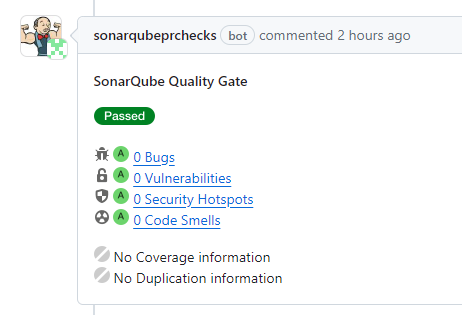

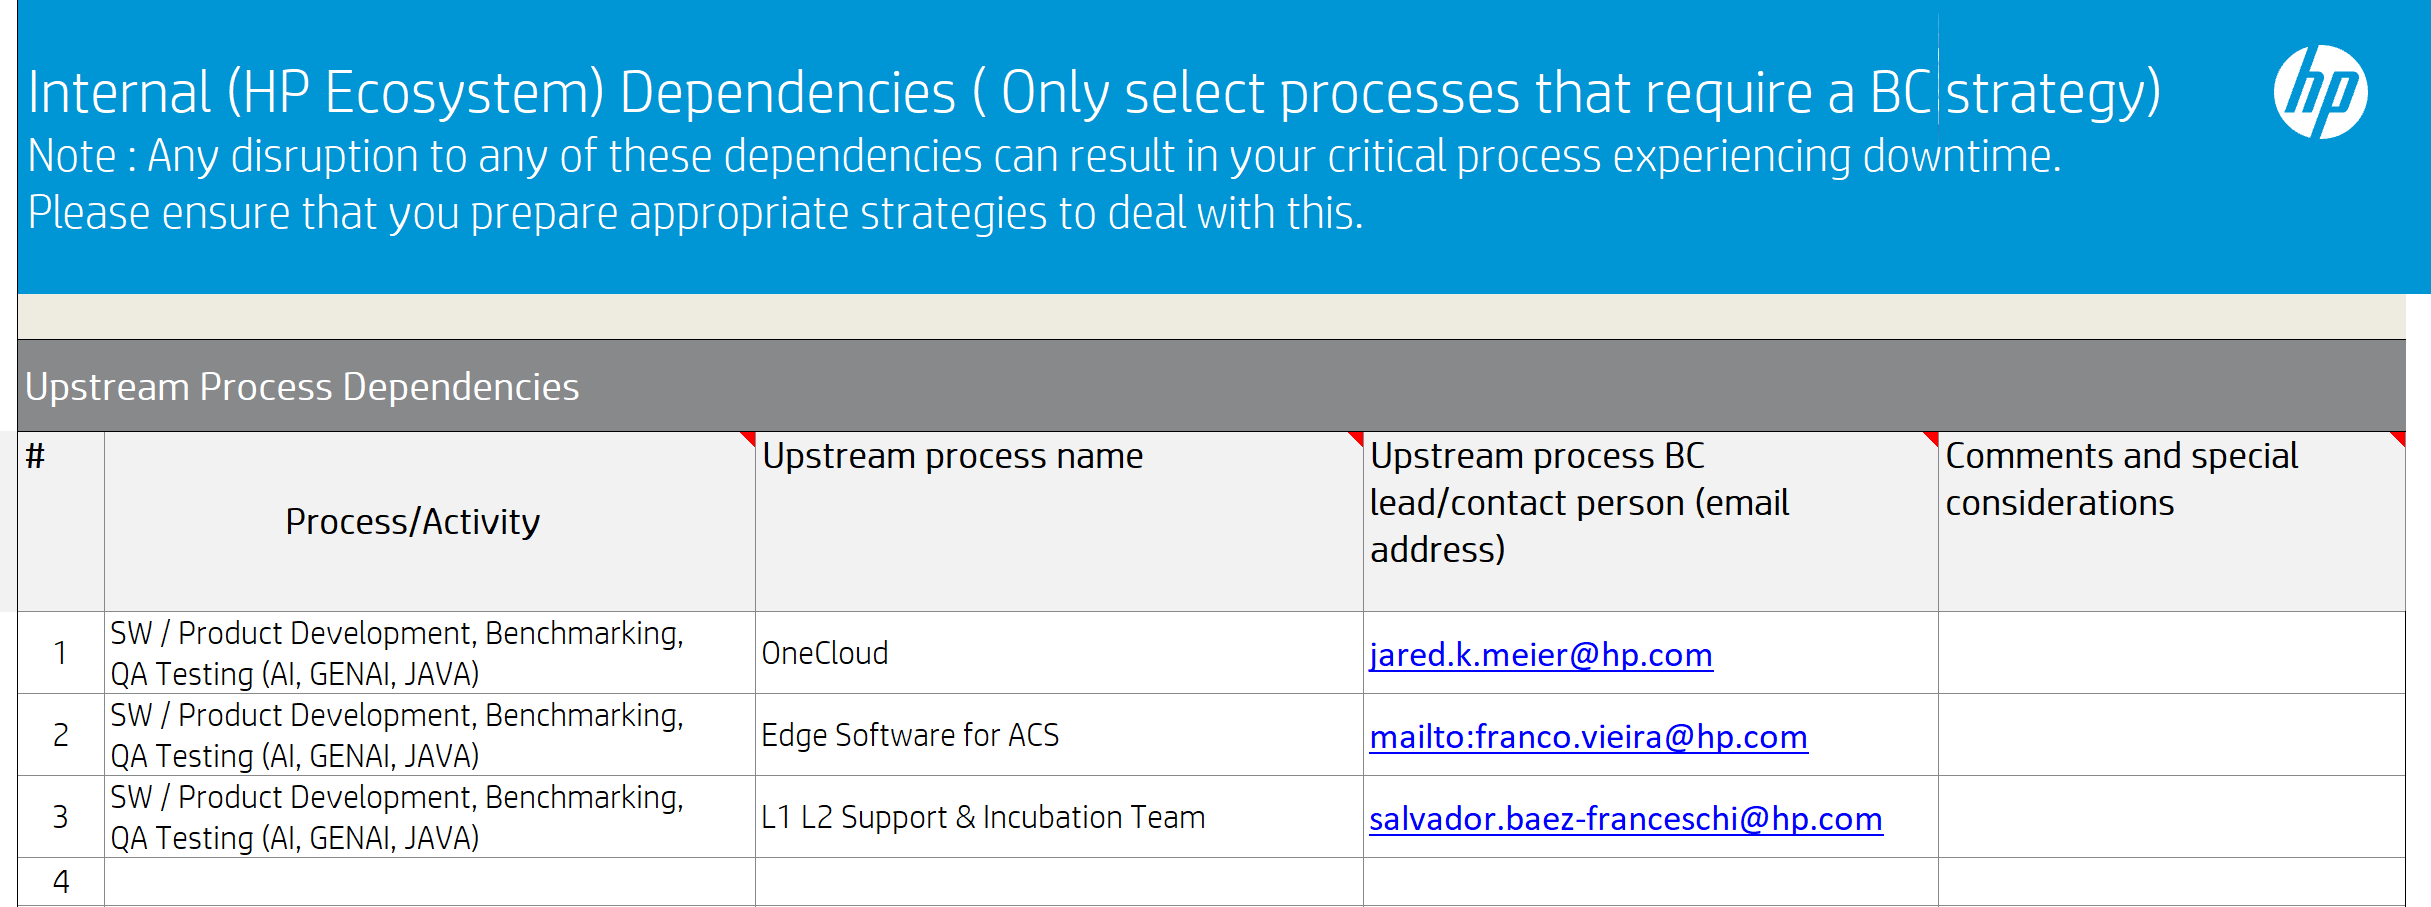

------------------------------------------------------------

2025-10-10 18:43:18 - INFO - Processing query: 'What are some feature flags that I can enable in AIStudio?'...
2025-10-10 18:43:18 - INFO - Starting ADO Wiki clone process...
2025-10-10 18:43:18 - INFO - Cloning wiki 'Phoenix-DS-Platform.wiki' to temporary directory: /tmp/tmpvzft976l
2025-10-10 18:45:35 - INFO - Scanning for Markdown files...
2025-10-10 18:45:35 - INFO - → Found 616 Markdown pages.
2025-10-10 18:45:35 - INFO - Copying referenced images to /tmp/tmpr_ow74tj/images...
2025-10-10 18:45:37 - INFO - → 855 unique images copied.
2025-10-10 18:45:37 - INFO - Assembling flat JSON structure...
2025-10-10 18:45:37 - INFO - ✅ Wiki data successfully cloned to /tmp/tmpr_ow74tj
2025-10-10 18:45:37 - INFO - Cleaned up temporary directory: /tmp/tmpvzft976l
2025-10-10 18:45:37 - WARNING - ⚠️ 113 broken image refs filtered out


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

------------------------------------------------------------
❓ Query:
What are some feature flags that I can enable in AIStudio?

🤖 Reply:


You can enable feature flags in AIStudio for the following features:

1. **Azure datasets**: Use the feature flag `azure` to include Azure datasets in the dataset types.
2. **GCP datasets**: Use the feature flag `gcp` to include GCP datasets in the dataset types.
3. **NVIDIA integration**: Use the feature flag `ngc` to enable integration with NVIDIA.

These flags are stored in the `features.yaml` file located at `%localappdata%/HP/AIStudio/`. You can manage them using the `hooh` tool, as described in the context.


📊 Faithfulness: 80.00% | Relevance: 80.00% | Conciseness: 80.00%
⏱️ Generation Time: 5.94s

 Total Pipeline Time: 285.14s

📚 Displaying 5 referenced document(s):


- `Phoenix/How%2Dto-articles/How-to-generate-new-feature-flag.md`
- `Phoenix/Development/Standards-and-Best-Practices/Development-Flow.md`
- `Phoenix/Feature-Flags.md`
- `Phoenix/Development/Feature-Flags/Using-Feature-Flags-in-your-code.md`
- `Phoenix/Documentation/DevOps/Newsletters/Newsletter-1-%2D-Database-Schema-Migrations,-Status-badges-and-Sonar-Bot.md`


🖼️ Displaying 2 retrieved image(s):


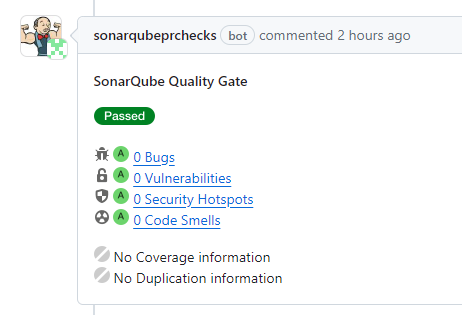

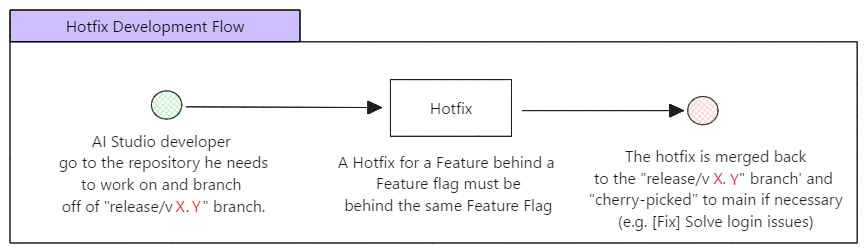

------------------------------------------------------------

2025-10-10 18:48:03 - INFO - Processing query: 'How do I manually clean my environment without hooh?'...
2025-10-10 18:48:03 - INFO - Starting ADO Wiki clone process...
2025-10-10 18:48:03 - INFO - Cloning wiki 'Phoenix-DS-Platform.wiki' to temporary directory: /tmp/tmp7_t6xiq5
2025-10-10 18:49:03 - INFO - Scanning for Markdown files...
2025-10-10 18:49:03 - INFO - → Found 616 Markdown pages.
2025-10-10 18:49:03 - INFO - Copying referenced images to /tmp/tmp_vchedaa/images...
2025-10-10 18:49:05 - INFO - → 855 unique images copied.
2025-10-10 18:49:05 - INFO - Assembling flat JSON structure...
2025-10-10 18:49:05 - INFO - ✅ Wiki data successfully cloned to /tmp/tmp_vchedaa
2025-10-10 18:49:05 - INFO - Cleaned up temporary directory: /tmp/tmp7_t6xiq5
2025-10-10 18:49:05 - WARNING - ⚠️ 113 broken image refs filtered out


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

------------------------------------------------------------
❓ Query:
How do I manually clean my environment without hooh?

🤖 Reply:


To manually clean your environment without using Hooh, follow these steps:

1. Access the AIStudio directory by typing `%localappdata%` in your explorer.
2. Navigate to the `HP` directory and then `AiStudio`.
3. Delete the directories that have either an `Account ID`, the `db`, and `creds` directories, as circled in the image.
4. Delete the `userconfig` file, as it stores environment-specific variables.
5. In the start menu, search for "Windows Credentials" and open the first result.
6. Select Windows Credentials and remove both `hp-aistudio-app` and `hp-aistudio-mongodb` as shown in the image.

These steps will help you manually clean your environment.


📊 Faithfulness: 90.00% | Relevance: 0.00% | Conciseness: 30.00%
⏱️ Generation Time: 7.19s

 Total Pipeline Time: 199.17s

📚 Displaying 5 referenced document(s):


- `Phoenix/Tools/Hooh.md`
- `Phoenix/How%2Dto-articles/How-to-manually-clean--your-environment.md`
- `Phoenix/Development/RFCs/Jobs/Job-Container-Image-Integration.md`
- `Phoenix/Incident-Management-and-Incident-Response.md`
- `Phoenix/Documentation/DevOps/Newsletters/Newsletter-1-%2D-Database-Schema-Migrations,-Status-badges-and-Sonar-Bot.md`


🖼️ Displaying 2 retrieved image(s):


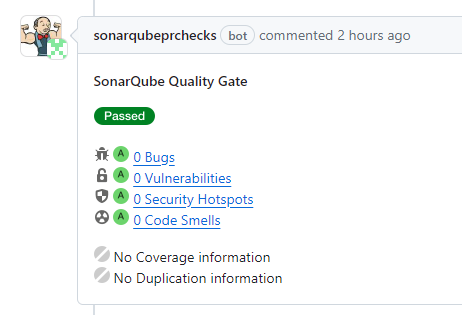

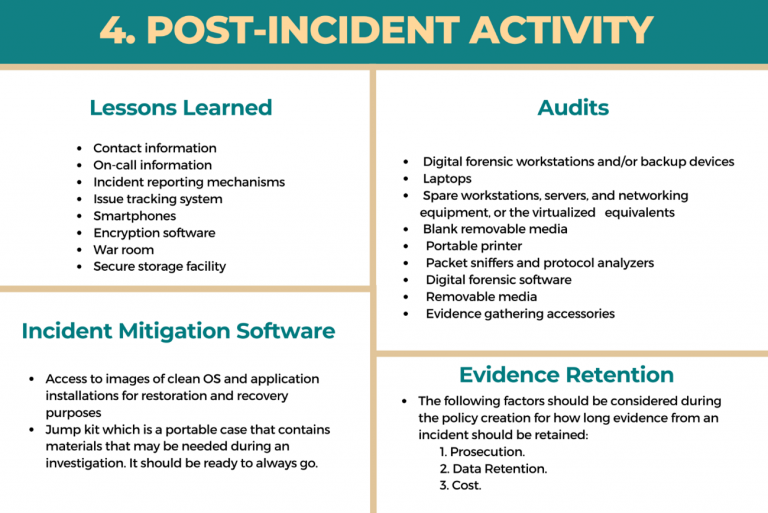

------------------------------------------------------------

CPU times: user 6min 36s, sys: 30.4 s, total: 7min 6s
Wall time: 12min 10s


In [17]:
%%time

all_results = []

if loaded_model:
    logger.info("--- Running sample inference with the loaded model ---")
    
    try:
        # 1. Load config and secrets ONCE before making queries.
        config = load_config(CONFIG_PATH)
        ADO_PAT = os.getenv("AIS_ADO_TOKEN")
        if not ADO_PAT:
            logger.info("Environment variable not found. Falling back to secrets.yaml.")
            secrets = load_secrets(SECRETS_PATH)
            ADO_PAT = secrets.get('AIS_ADO_TOKEN')

        # 2. Construct the payload dictionary that will be sent with each request.
        request_payload_dict = {
            "config": config,
            "secrets": {"AIS_ADO_TOKEN": ADO_PAT}
        }
        
        sample_queries = [
            "What are the AI Blueprints Repository best practices?",
            "What are some feature flags that I can enable in AIStudio?",
            "How do I manually clean my environment without hooh?",
        ]

        # 3. For each query, send BOTH the query and the payload.
        for query in sample_queries:
            logger.info(f"Processing query: '{query}'...")
            
            # Create the DataFrame that matches the model's signature
            prediction_df = pd.DataFrame([{
                "query": query,
                "payload": json.dumps(request_payload_dict),
            }])
            
            result_df = loaded_model.predict(prediction_df)
            result_df['query'] = query
            display_results(query, result_df)

            all_results.append(result_df)

    except Exception as e:
        logger.error(f"Prediction failed: {e}", exc_info=True)

    # --- ADD: Combine all individual results into one DataFrame ---
    if all_results:
        final_results_df = pd.concat(all_results, ignore_index=True)
    else:
        final_results_df = pd.DataFrame()

else:
    logger.warning("Skipping sample inference because the model was not loaded.")
    # --- ADD: Ensure the variable exists ---
    final_results_df = pd.DataFrame()

## Step 5: Log Hallucinations & Relevance Evaluations to MlFlow

In [18]:
if loaded_model and 'run_id' in locals() and not final_results_df.empty:
    logger.info(f"--- Reopening original run ({run_id}) to log pre-computed evaluations ---")

    # The results_df already contains the scores from the `predict` calls
    results_df = final_results_df
    
    # Reopen the existing run using its ID
    with mlflow.start_run(run_id=run_id) as run:
        logger.info("Successfully reopened existing run. Logging metrics and artifacts...")

        # Calculate average scores from the DataFrame
        avg_faithfulness = results_df["faithfulness"].astype(float).mean()
        avg_relevance = results_df["relevance"].astype(float).mean()
        avg_conciseness = results_df["conciseness"].astype(float).mean()
        avg_pipeline_time = results_df["total_pipeline_time_seconds"].astype(float).mean()

        # Log the average scores as metrics
        mlflow.log_metrics({
            "avg_faithfulness": avg_faithfulness,
            "avg_relevance": avg_relevance,
            "avg_conciseness": avg_conciseness,
            "avg_pipeline_time_seconds": avg_pipeline_time,
        })

        # Log the detailed results as a table artifact
        mlflow.log_table(
            data=results_df[['query', 'reply', 'faithfulness', 'conciseness', 'relevance', 'total_pipeline_time_seconds']], 
            artifact_file="stateless_evaluation_results.json"
        )
        
        logger.info("✅ Successfully logged metrics and artifacts to the original model run.")

else:
    logger.warning("Skipping evaluation logging because the model was not loaded, run_id was not found, or no results were generated.")

2025-10-10 18:51:23 - INFO - --- Reopening original run (998eba083bf2404784d1de878b1bd45c) to log pre-computed evaluations ---
2025-10-10 18:51:23 - INFO - Successfully reopened existing run. Logging metrics and artifacts...
2025-10-10 18:51:24 - INFO - ✅ Successfully logged metrics and artifacts to the original model run.


In [19]:
end_time: float = time.time()
elapsed_time: float = end_time - start_time
elapsed_minutes: int = int(elapsed_time // 60)
elapsed_seconds: float = elapsed_time % 60

logger.info(f"⏱️ Total execution time: {elapsed_minutes}m {elapsed_seconds:.2f}s")

2025-10-10 18:51:24 - INFO - ⏱️ Total execution time: 16m 46.29s
2025-10-10 18:51:24 - INFO - ✅ Notebook execution completed.


In [1]:
status = "Notebook execution completed successfully"
print(f"Message: {status}")

Message: Notebook execution completed successfully


In [ ]:
app = get_ipython()
app.kernel.do_shutdown(restart=False)

Built with ❤️ using HP AI Studio.